<a href="https://colab.research.google.com/github/RabinPhuyal/Deep-Learning-with-Pytorch/blob/main/Pytorch_Neural_Network_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import make_circles

#Make 1000 samples
n_samples = 1000

#Make Circle
X,y = make_circles(n_samples,noise=0.03,random_state = 42)

In [2]:
#lets view first 5 values

print(f"First 5 X features: \n{X[:5]}")
print(f"\nFirst 5 y labels: {y[:5]}")

First 5 X features: 
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels: [1 1 1 1 0]


In [3]:
#Make DataFrame of circle data

import pandas as pd
circles = pd.DataFrame({"X1":X[:,0],"X2":X[:,1],"label":y})

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [4]:
#Check different labels
circles.label.value_counts()

,count
label,
1,500
0,500


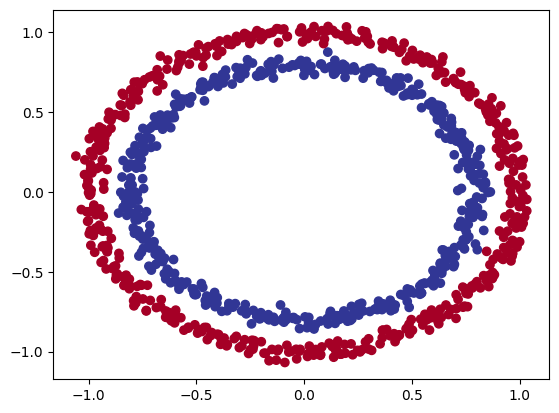

In [5]:
#Visualize with plot

import matplotlib.pyplot as plt

plt.scatter(x=X[:,0],y=X[:,1],c=y,cmap=plt.cm.RdYlBu)

In [6]:
#Check shapes of features and labels

X.shape, y.shape

((1000, 2), (1000,))

In [7]:
#Lets view the first sample of our features and labels

X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shape for one sampe of X: {X_sample.shape} and the same for y:{y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shape for one sampe of X: (2,) and the same for y:()


In [8]:
#Turn data into tensors
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [9]:
#Splitting data into train and test set
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

In [10]:
#Standard pytorch imports
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [11]:
# 1. Construct a model class that subclasses nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features (X), produces 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features, produces 1 feature (y)

    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

# 4. Create an instance of the model and send it to target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [12]:
#Replicate CircleModelV0 with nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [13]:
#Make Predictions with the model

untrained_preds = model_0(X_test.to(device))

print(f"Length of untrained predictions: {len(untrained_preds)} , Shape: {untrained_preds.shape}")
print(f"Lenght of test samples: {len(y_test)} , Shape: {y_test.shape}")
print(f"First 10 predictions:\n {untrained_preds[:10]}")
print(f"First 10 labels:\n {y_test[:10]}")

Length of untrained predictions: 200 , Shape: torch.Size([200, 1])
Lenght of test samples: 200 , Shape: torch.Size([200])
First 10 predictions:
 tensor([[0.0545],
        [0.1234],
        [0.0123],
        [0.0658],
        [0.2323],
        [0.2727],
        [0.2925],
        [0.3280],
        [0.0031],
        [0.1305]], device='cuda:0', grad_fn=<SliceBackward0>)
First 10 labels:
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [14]:
#Create a Loss Function

# loss_fn = nn.BCELoss()

#Loss function with sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss()

#Create a optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.1)

In [15]:
#Calculate accuracy

def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_true))*100
  return acc

In [16]:
#Going from raw model outputs to predicted labels
#View the first 5 outputs of the forward pass

y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[0.0545],
        [0.1234],
        [0.0123],
        [0.0658],
        [0.2323]], device='cuda:0', grad_fn=<SliceBackward0>)

In [17]:
#Use sigmoid on model logits

y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5136],
        [0.5308],
        [0.5031],
        [0.5165],
        [0.5578]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [18]:
#Find the predicted labels
y_preds = torch.round(y_pred_probs)

#In Full
y_preds_label = torch.round(torch.sigmoid(model_0(X_test.to(device)))[:5])

#Check for equality
print(torch.eq(y_preds.squeeze(),y_preds_label.squeeze()))

#Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 1., 1., 1.], device='cuda:0', grad_fn=<SqueezeBackward0>)

In [19]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [20]:
### Building a training and testing loop

torch.manual_seed(42)

#Set the number of epochs
epochs = 100

#Put the data in to target devices
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

#Builing training and evaluation loop

for epoch in range(epochs):
  ### Training
  model_0.train()

  #1. Forward Pass(Model ouputs are raw logits)
  y_logits = model_0(X_train).squeeze() #Squeeze to remove extra '1' dimension

  y_pred = torch.round(torch.sigmoid(y_logits))

  #2. Calculate loss/accuracy

  #loss = loss_fn(torch.sigmoid(y_logits),y_train) #Using nn.BCELoss you need torch.sigmoid()

  loss = loss_fn(y_logits,y_train)

  acc = accuracy_fn(y_true = y_train,y_pred = y_pred)

  #3. Optimize zero grad
  optimizer.zero_grad()

  #4. Loss Backwards()
  loss.backward()

  #5.Optimizer Step
  optimizer.step()

  ### Testing

  model_0.eval()

  with torch.inference_mode():

    #1. Forward Pass
    test_logits = model_0(X_test).squeeze()

    test_pred = torch.round(torch.sigmoid(test_logits))

    #2. Calculate loss/forward
    test_loss = loss_fn(test_logits,y_test)

    test_acc = accuracy_fn(y_true = y_test ,y_pred = test_pred)

    #Print out what's happening every 10 epochs

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test_Acc: {test_acc:.2f}% ")

Epoch: 0 | Loss: 0.69717 | Accuracy: 55.62% | Test Loss: 0.69868 | Test_Acc: 53.00% 
Epoch: 10 | Loss: 0.69539 | Accuracy: 52.75% | Test Loss: 0.69691 | Test_Acc: 53.00% 
Epoch: 20 | Loss: 0.69457 | Accuracy: 51.38% | Test Loss: 0.69611 | Test_Acc: 50.50% 
Epoch: 30 | Loss: 0.69413 | Accuracy: 51.50% | Test Loss: 0.69572 | Test_Acc: 50.50% 
Epoch: 40 | Loss: 0.69385 | Accuracy: 51.00% | Test Loss: 0.69551 | Test_Acc: 51.00% 
Epoch: 50 | Loss: 0.69367 | Accuracy: 50.75% | Test Loss: 0.69539 | Test_Acc: 49.50% 
Epoch: 60 | Loss: 0.69353 | Accuracy: 50.88% | Test Loss: 0.69532 | Test_Acc: 49.00% 
Epoch: 70 | Loss: 0.69342 | Accuracy: 50.62% | Test Loss: 0.69527 | Test_Acc: 49.00% 
Epoch: 80 | Loss: 0.69334 | Accuracy: 51.38% | Test Loss: 0.69524 | Test_Acc: 49.00% 
Epoch: 90 | Loss: 0.69327 | Accuracy: 51.00% | Test Loss: 0.69522 | Test_Acc: 48.50% 


In [21]:
### Make Prediction and evaluate the model

In [22]:
import requests
from pathlib import Path

#Download the helper function from learn Pytorch repo

if Path("helper_function.py").is_file():
  print("helper_function.py already exists, skipping download")
else:
  print("Downloading helper_function.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open ("helper_function.py","wb") as f:
    f.write(request.content)

from helper_function import plot_predictions, plot_decision_boundary


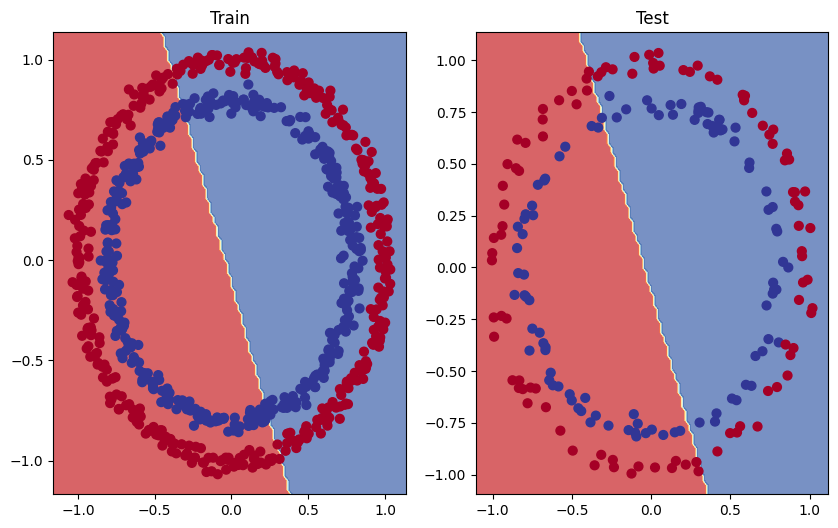

In [23]:
#Plot decision boundary for training and testing sets

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [24]:
# Preparing data to see if our model can model a straight line

In [25]:
# Create some data
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

#Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

#Check the data
print(X_regression[:5], y_regression[:5])

tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400]]) tensor([[0.3000],
        [0.3070],
        [0.3140],
        [0.3210],
        [0.3280]])


In [26]:
#Create train and test split
train_split = int(0.8 * len(X_regression))

X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

#Check the lenght of each split
print(len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression))

80 80 20 20


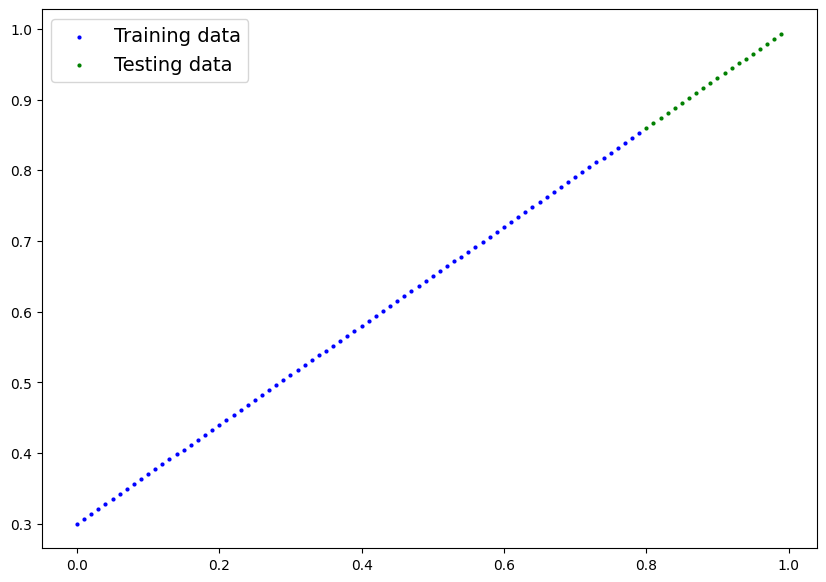

In [27]:
#Now lets plot the above data using plot_predictions
plot_predictions(train_data = X_train_regression,
                 train_labels = y_train_regression,
                 test_data = X_test_regression,
                 test_labels = y_test_regression)

In [28]:
# Adjusting model_1 to fit a straight line

#Same architecture as model_1 but using nn.Sequential

model_2 = nn.Sequential(
    nn.Linear(in_features = 1, out_features=10),
    nn.Linear(in_features = 10, out_features = 10),
    nn.Linear(in_features = 10, out_features = 1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [29]:
#Set up loss function and optmizer

loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr = 0.1)

In [31]:
# Train the model
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data to target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    ### Training
    # 1. Forward pass
    y_pred = model_2(X_train_regression)

    # 2. Calculate loss (no accuracy since it's a regression problem, not classification)
    loss = loss_fn(y_pred, y_train_regression)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_pred = model_2(X_test_regression)
      # 2. Calculate the loss
      test_loss = loss_fn(test_pred, y_test_regression)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")

Epoch: 0 | Train loss: 0.06454, Test loss: 0.02425
Epoch: 100 | Train loss: 0.05295, Test loss: 0.00773
Epoch: 200 | Train loss: 0.05297, Test loss: 0.00613
Epoch: 300 | Train loss: 0.05887, Test loss: 0.01263
Epoch: 400 | Train loss: 0.05554, Test loss: 0.01104
Epoch: 500 | Train loss: 0.06255, Test loss: 0.00561
Epoch: 600 | Train loss: 0.05861, Test loss: 0.00864
Epoch: 700 | Train loss: 0.05844, Test loss: 0.01513
Epoch: 800 | Train loss: 0.04373, Test loss: 0.01978
Epoch: 900 | Train loss: 0.05336, Test loss: 0.02989


In [32]:
#6. The missing piece: Non-linearity

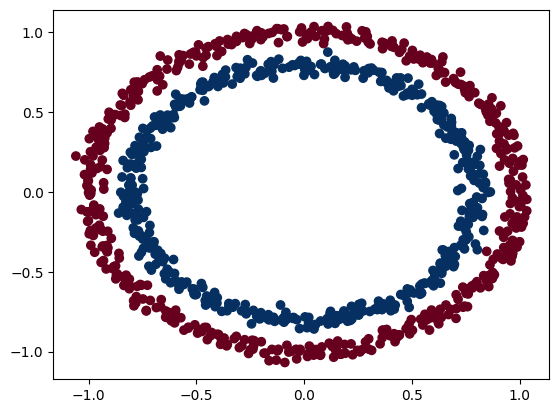

In [35]:
#6.1 Recreating non-linear data
#Make and plot data

import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X,y= make_circles(n_samples = 1000, noise = 0.03, random_state = 42)

plt.scatter(X[:,0] , X[:,1], c=y, cmap = plt.cm.RdBu)

In [37]:
#Convert to tensor and split into train and test sets
import torch
from sklearn.model_selection import train_test_split

#Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

#Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X , y,
                                                    test_size = 0.2,
                                                    random_state = 42)

X_train[:5],y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [38]:
#6.2 Building a model with non-linearity